In [44]:
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
cdf_fn = Path('../logs/sub-gilles/session-01/sub-gilles_ses-01_task-training.cdf_events.tsv').resolve()
df_cdf = pd.read_csv(cdf_fn, sep='\t')
inv_cdf_fn = Path('../logs/sub-gilles/session-01/sub-gilles_ses-01_task-training.inverse_cdf_events.tsv').resolve()
df_inv_cdf = pd.read_csv(inv_cdf_fn, sep='\t')

df = pd.concat([df_cdf, df_inv_cdf], keys=['cdf', 'inv_cdf'], names=['mapping'])
df = df[df.phase == 4]


df['response'] = df['response'].astype(float)

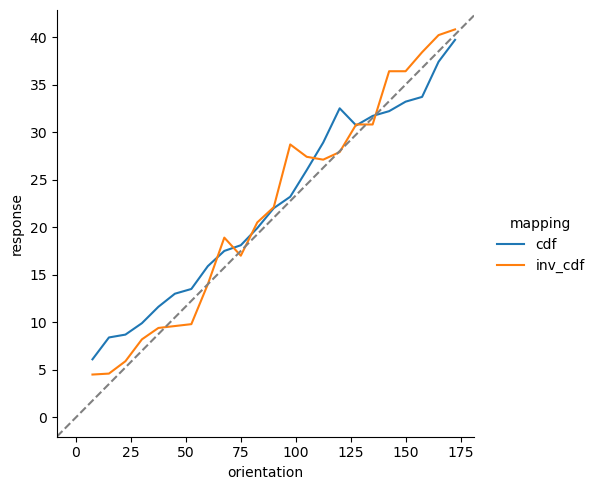

In [46]:
g = sns.relplot(x='orientation', y='response', data=df, kind='line', errorbar=None, hue='mapping')

# g.map_dataframe(sns.scatterplot, x='orientation', y='response')
# g.map_dataframe(sns.lineplot, x='orientation', y='value', color='red')

g.map(plt.axline, xy1=(0, 0), slope=42/180, color='gray', linestyle='--')

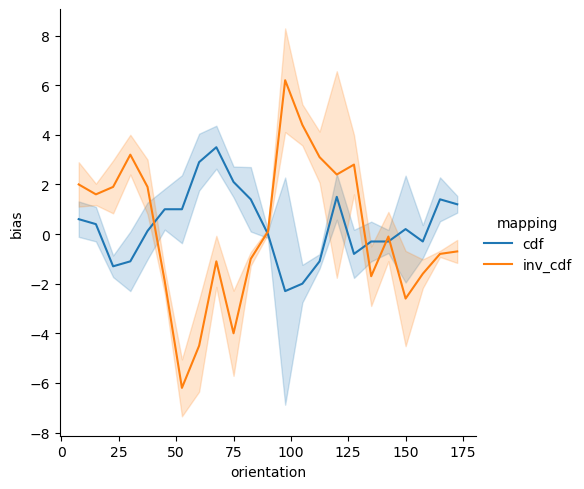

In [57]:
df['bias'] = df['response'] - df['value']

# Leave out response of more than sd 2.5
df['outlier'] = df.groupby(['mapping', 'value'])['bias'].transform(
    lambda x: (x - x.mean()).abs() > 1.5 * x.std()
)
# df = df[~df['outlier']]

sns.relplot(x='orientation', y='bias', data=df, kind='line', errorbar='se', hue='mapping')

,mapping,orientation,variance
0,cdf,7.5,1.376264
1,cdf,15.0,1.701853
2,cdf,22.5,1.818830
3,cdf,30.0,1.866879
4,cdf,37.5,2.103153
5,cdf,45.0,2.420077
6,cdf,52.5,2.271651
7,cdf,60.0,2.091792
8,cdf,67.5,2.304886
9,cdf,75.0,1.827874


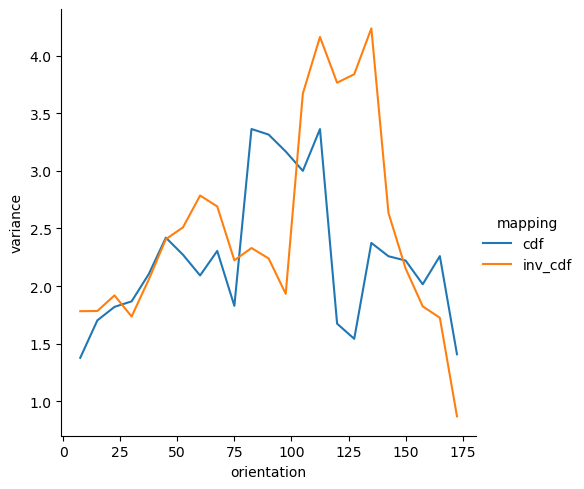

In [60]:
var = df.groupby(['mapping', 'orientation'])['response'].std().to_frame('variance').reset_index()

# Smooth over orientations by rolling mean
# var['orientation'] = var['orientation'].astype(float)
# # var = var.sort_values('orientation')
var['variance'] = var.groupby('mapping')['variance'].transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean())

sns.relplot(x='orientation', y='variance', data=var, kind='line', errorbar='se', hue='mapping')

var

In [42]:
df

trial_nr        onset event_type  phase  response  nr_frames  \
mapping                                                                     
cdf     7           2    11.752707   feedback      4      22.5      175.0   
        13          3    22.852985   feedback      4      26.0      180.0   
        19          4    32.315559   feedback      4      26.0      180.0   
        25          5    42.188259   feedback      4      36.0      182.0   
        31          6    51.770642   feedback      4       6.0      180.0   
...               ...          ...        ...    ...       ...        ...   
inv_cdf 674       116  1111.414864   feedback      4       9.5      181.0   
        680       117  1119.830731   feedback      4       9.5      180.0   
        686       118  1130.582873   feedback      4      11.5      181.0   
        692       119  1139.098323   feedback      4      11.5      180.0   
        698       120  1149.108918   feedback      4      11.5      177.0   

             orientation  value  response_time    onset_abs  duration  bias  \
mapping                                                                       
cdf     7           90.0   22.0       2.613604    14.508245  1.514169   0.5   
        13          97.5   25.5       3.715524    25.608522  1.499609   0.5   
        19         105.0   28.0       3.162638    35.071097  1.503175  -2.0   
        25         120.0   31.0       3.035570    44.943797  1.513952   5.0   
        31          15.0    8.0       2.590810    54.526180  1.510983  -2.0   
...                  ...    ...            ...          ...       ...   ...   
inv_cdf 674         30.0    5.0       2.352125  1114.309826  1.511440   4.5   
        680         45.0   11.5       0.762735  1122.725693  1.512233  -2.0   
        686         60.0   18.5       1.503348  1133.477835  1.510119  -7.0   
        692         75.0   21.0       0.001319  1141.993285  1.498392  -9.5   
        698        120.0   25.5       0.001544  1152.003880  1.504251 -14.0   

             outlier  
mapping               
cdf     7      False  
        13     False  
        19     False  
        25     False  
        31     False  
...              ...  
inv_cdf 674    False  
        680    False  
        686    False  
        692    False  
        698    False  

[230 rows x 13 columns]

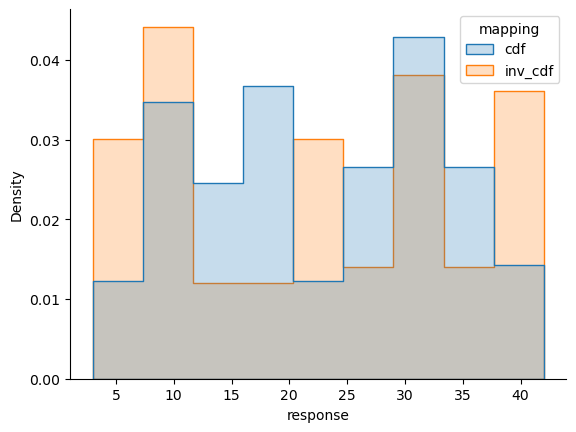

In [43]:
sns.histplot(data=df, x='response', hue='mapping', element='step', stat='density', common_norm=False)

sns.despine()

In [21]:
df['response']

Series([], Name: response, dtype: object)

In [63]:
df['orientation'].nunique()

23

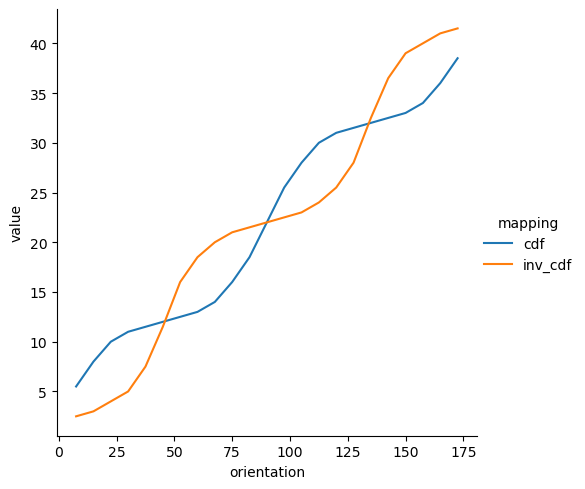

In [67]:
sns.relplot(x='orientation', y='value', data=df, kind='line', errorbar=None, hue='mapping')